# Semana 3: LightGCN para Recomendación de Tweets

**Dataset:** Twitter15/16 (rumores y fake news)  
**Objetivo:** Implementar LightGCN y comparar su rendimiento contra el baseline GCN de la semana pasada

LightGCN es una versión simplificada y más efectiva de GCN para tareas de recomendación. La idea principal es eliminar las transformaciones de features y activaciones no lineales, dejando solo la propagación de información a través del grafo. En la práctica, LightGCN suele superar a GCN en métricas de ranking.

## Descarga de datos desde GitHub

Descargamos los archivos necesarios directo desde el repo.

In [ ]:
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_h1/train_interactions_idx.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_h1/test_interactions_idx.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_h1/item_labels.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs/bipartite_graph.pt
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs/social_graph.pt

print("Archivos descargados ✓")

Archivos descargados ✓


## Instalación de dependencias

In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Fijar seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.3 MB/s eta 0:00:00
PyTorch version: 2.8.0+cu126
CUDA available: True


## Carga de datos y construcción del grafo

Cargamos los datos procesados y construimos el grafo bipartito solo con las interacciones de entrenamiento para evitar data leakage.

In [ ]:
# Cargar grafos
print("Cargando grafos...")
bipartite_graph = torch.load('bipartite_graph.pt', weights_only=False)
social_graph = torch.load('social_graph.pt', weights_only=False)

# Cargar datos tabulares
print("Cargando datasets...")
train_df = pd.read_csv('train_interactions_idx.csv')
test_df = pd.read_csv('test_interactions_idx.csv')
labels_df = pd.read_csv('item_labels.csv')

num_users = bipartite_graph['num_users']
num_items = bipartite_graph['num_items']

# Construir grafo bipartito solo con train interactions
print("\nConstruyendo grafo de entrenamiento...")
train_edges = []
for _, row in train_df.iterrows():
    u, i = row['user_idx'], row['item_idx']
    train_edges.append([u, num_users + i])
    train_edges.append([num_users + i, u])

train_edge_index = torch.LongTensor(train_edges).t().contiguous()

print(f"\nEstadísticas:")
print(f"  Users: {num_users}")
print(f"  Items: {num_items}")
print(f"  Train edges: {train_edge_index.shape[1]}")
print(f"  Test interactions: {len(test_df)}")

Cargando grafos...
Cargando datasets...

Construyendo grafo de entrenamiento...

Estadísticas:
  Users: 4856
  Items: 2308
  Train edges: 117988
  Test interactions: 4856


## Implementación de LightGCN

LightGCN simplifica el diseño de GCN eliminando transformaciones de features y funciones de activación. Solo aprende embeddings de users e items y los propaga por el grafo, promediando las representaciones de todas las capas.

**Diferencias clave con GCN:**
- No usa features pre-entrenadas (BERT)
- No tiene transformaciones lineales en cada capa
- No usa activaciones no lineales (ReLU)
- Promedia embeddings de todas las capas (layer combination)

In [ ]:
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=128, num_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers

        # Embeddings aprendibles para users e items
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        # Capas de propagación (sin parámetros, solo smoothing)
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

        # Inicialización Xavier
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def forward(self, edge_index):
        # Embeddings iniciales
        x = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)

        # Guardar embeddings de cada capa (incluyendo la inicial)
        all_embeddings = [x]

        # Propagación a través de las capas
        for conv in self.convs:
            x = conv(x, edge_index)
            all_embeddings.append(x)

        # Promedio de todas las capas (layer combination)
        final_emb = torch.stack(all_embeddings, dim=0).mean(dim=0)

        # Separar users e items
        user_emb = final_emb[:self.num_users]
        item_emb = final_emb[self.num_users:]

        return user_emb, item_emb

    def predict(self, user_emb, item_emb, user_idx):
        """Calcula scores de un usuario con todos los items"""
        user_vec = user_emb[user_idx]
        scores = torch.matmul(user_vec, item_emb.t())
        return scores

print("Modelo LightGCN definido ✓")

Modelo LightGCN definido ✓


## Función de entrenamiento (BPR Loss)

Igual que en GCN, usamos Bayesian Personalized Ranking. La única diferencia es que LightGCN no necesita features de items como input.

In [ ]:
def train_epoch(model, edge_index, train_interactions, optimizer, device):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    user_emb, item_emb = model(edge_index)

    # Crear dict de items por usuario para negative sampling
    user_items_dict = train_interactions.groupby('user_idx')['item_idx'].apply(set).to_dict()

    # Interacciones positivas
    pos_users = torch.LongTensor(train_interactions['user_idx'].values).to(device)
    pos_items = torch.LongTensor(train_interactions['item_idx'].values).to(device)

    # Negative sampling: items que el usuario NO consumió
    neg_items_list = []
    for user_idx in pos_users.cpu().numpy():
        consumed = user_items_dict.get(user_idx, set())
        available = list(set(range(model.num_items)) - consumed)
        if available:
            neg_items_list.append(random.choice(available))
        else:
            neg_items_list.append(random.randint(0, model.num_items - 1))

    neg_items = torch.LongTensor(neg_items_list).to(device)

    # Calcular scores
    pos_scores = (user_emb[pos_users] * item_emb[pos_items]).sum(dim=1)
    neg_scores = (user_emb[pos_users] * item_emb[neg_items]).sum(dim=1)

    # BPR Loss
    loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()

    loss.backward()
    optimizer.step()

    return loss.item()

print("Función de training lista ✓")

Función de training lista ✓


## Evaluación

Generamos recomendaciones top-10 para cada usuario y calculamos métricas de ranking.

In [ ]:
@torch.no_grad()
def evaluate(model, edge_index, test_df, train_df, k=10, device='cpu'):
    model.eval()

    # Forward pass
    user_emb, item_emb = model(edge_index)

    # Items de train por usuario (para excluirlos)
    train_items_per_user = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    recommendations = []
    ground_truth = []

    for user_idx in range(model.num_users):
        # Calcular scores
        scores = model.predict(user_emb, item_emb, user_idx)

        # Excluir items ya vistos en train
        if user_idx in train_items_per_user:
            train_items = list(train_items_per_user[user_idx])
            scores[train_items] = -float('inf')

        # Top-k items
        _, top_items = torch.topk(scores, k)
        recommendations.append(top_items.cpu().tolist())

        # Ground truth
        true_items = test_df[test_df['user_idx'] == user_idx]['item_idx'].values
        ground_truth.append(set(true_items))

    return recommendations, ground_truth


def compute_metrics(recommendations, ground_truth, num_items):
    """Calcula MRR, ILD y Coverage"""
    # MRR
    reciprocal_ranks = []
    for rec_list, true_items in zip(recommendations, ground_truth):
        rank = None
        for i, item in enumerate(rec_list, 1):
            if item in true_items:
                rank = i
                break
        reciprocal_ranks.append(1.0 / rank if rank else 0.0)
    mrr = np.mean(reciprocal_ranks)

    # ILD
    similarities = []
    for i in range(len(recommendations)):
        for j in range(i + 1, len(recommendations)):
            set_i = set(recommendations[i])
            set_j = set(recommendations[j])
            intersection = len(set_i & set_j)
            union = len(set_i | set_j)
            jaccard = intersection / union if union > 0 else 0.0
            similarities.append(jaccard)
    ild = 1.0 - np.mean(similarities)

    # Coverage
    recommended_items = set()
    for rec_list in recommendations:
        recommended_items.update(rec_list)
    coverage = len(recommended_items) / num_items

    return {'MRR': mrr, 'ILD': ild, 'Coverage': coverage}

print("Funciones de evaluación listas ✓")

Funciones de evaluación listas ✓


## Entrenamiento de LightGCN

Entrenamos con embeddings de dimensión 128 y 3 capas de propagación. LightGCN suele converger un poco más rápido que GCN.

Using device: cuda

Modelo LightGCN:
  Parámetros: 916,992
  Embedding dim: 128
  Num layers: 3

Entrenando...


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch 30/150 - Loss: 0.6659
Epoch 60/150 - Loss: 0.5399
Epoch 90/150 - Loss: 0.3929
Epoch 120/150 - Loss: 0.3128
Epoch 150/150 - Loss: 0.2744


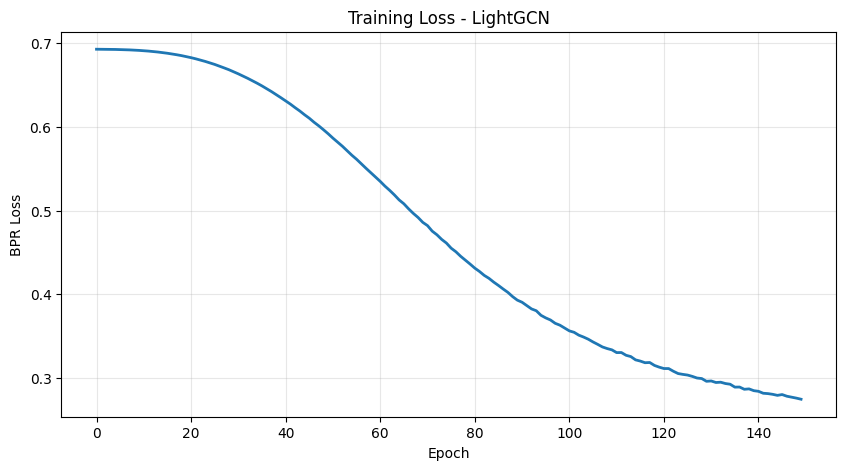


Entrenamiento completado ✓


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Mover datos a GPU
train_edge_index = train_edge_index.to(device)

# Crear modelo
model_lightgcn = LightGCN(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=128,
    num_layers=3
).to(device)

optimizer = torch.optim.Adam(model_lightgcn.parameters(), lr=0.001, weight_decay=1e-5)

print(f"\nModelo LightGCN:")
print(f"  Parámetros: {sum(p.numel() for p in model_lightgcn.parameters()):,}")
print(f"  Embedding dim: 128")
print(f"  Num layers: 3")

# Training loop
epochs = 150
losses = []

print("\nEntrenando...")
for epoch in tqdm(range(epochs)):
    loss = train_epoch(model_lightgcn, train_edge_index, train_df, optimizer, device)
    losses.append(loss)

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

# Plot de la loss
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title('Training Loss - LightGCN')
plt.grid(True, alpha=0.3)
plt.show()

print("\nEntrenamiento completado ✓")

## Evaluación de LightGCN

Generamos recomendaciones y calculamos métricas para ver el rendimiento de LightGCN.

In [ ]:
print("Evaluando modelo LightGCN...")
recs_lightgcn, gt_lightgcn = evaluate(model_lightgcn, train_edge_index,
                                       test_df, train_df, k=10, device=device)

metrics_lightgcn = compute_metrics(recs_lightgcn, gt_lightgcn, num_items)

print("\n" + "="*50)
print("RESULTADOS LIGHTGCN")
print("="*50)
for metric, value in metrics_lightgcn.items():
    print(f"{metric:12s}: {value:.4f}")
print("="*50)

Evaluando modelo LightGCN...

RESULTADOS LIGHTGCN
MRR         : 0.0508
ILD         : 0.8493
Coverage    : 0.1655


## Comparación con GCN (Semana 2)

Los resultados muestran cómo LightGCN se compara con GCN-BERT y GCN-Random de la semana anterior.


COMPARACIÓN: GCN vs LightGCN
                 MRR       ILD  Coverage
GCN-BERT    0.048100  0.900400  0.108800
GCN-Random  0.037600  0.895100  0.109600
LightGCN    0.050772  0.849275  0.165511


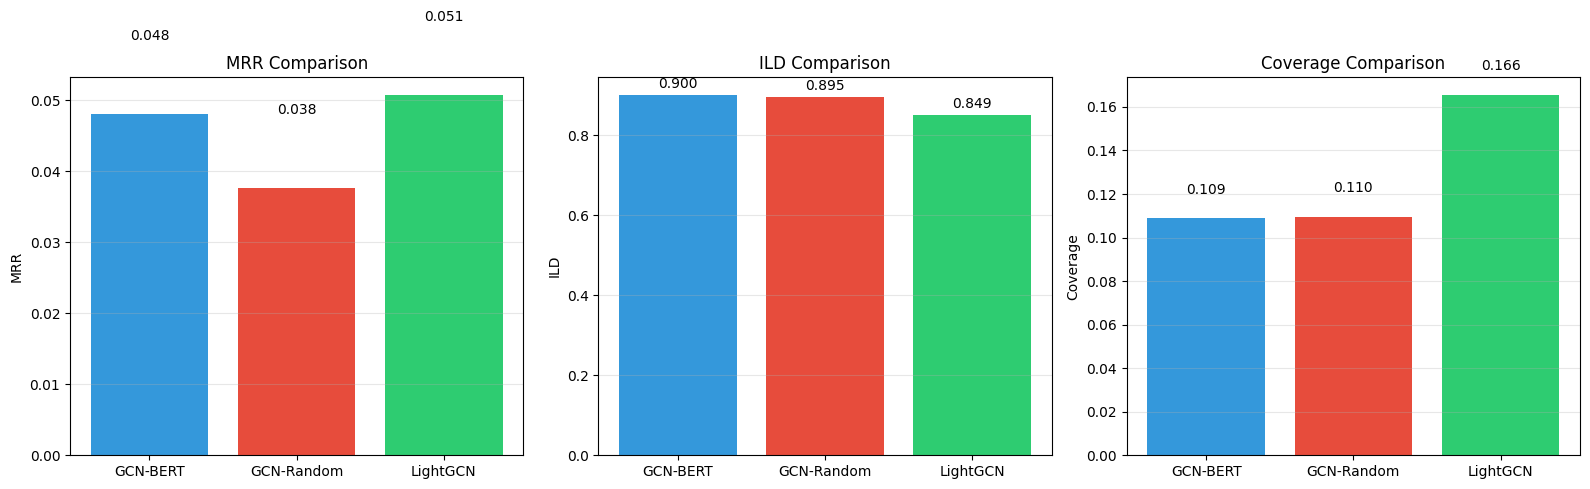

In [ ]:
# Resultados de GCN de la Semana 2 (valores reales del notebook anterior)
metrics_gcn_bert = {'MRR': 0.0481, 'ILD': 0.9004, 'Coverage': 0.1088}
metrics_gcn_random = {'MRR': 0.0376, 'ILD': 0.8951, 'Coverage': 0.1096}

comparison_df = pd.DataFrame({
    'GCN-BERT': metrics_gcn_bert,
    'GCN-Random': metrics_gcn_random,
    'LightGCN': metrics_lightgcn
})

print("\n" + "="*70)
print("COMPARACIÓN: GCN vs LightGCN")
print("="*70)
print(comparison_df.T.to_string())
print("="*70)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_names = ['MRR', 'ILD', 'Coverage']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, metric in enumerate(metrics_names):
    values = [metrics_gcn_bert[metric], metrics_gcn_random[metric], metrics_lightgcn[metric]]
    axes[i].bar(['GCN-BERT', 'GCN-Random', 'LightGCN'], values, color=colors)
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].grid(True, alpha=0.3, axis='y')

    for j, v in enumerate(values):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Análisis de propagación de Fake News

Repetimos el análisis de propagación con LightGCN para comparar cómo afecta la difusión de desinformación.

In [ ]:
# Linear Threshold Model
class LinearThresholdModel:
    def __init__(self, social_graph, seed=42):
        self.edge_index = social_graph['edge_index']
        self.num_nodes = social_graph['num_nodes']
        np.random.seed(seed)
        self.thresholds = np.random.uniform(0.3, 0.7, self.num_nodes)

    def simulate(self, seed_nodes, max_iterations=50):
        infected = set(seed_nodes)
        infection_rounds = [set(seed_nodes)]

        for iteration in range(max_iterations):
            new_infected = set()

            for node in range(self.num_nodes):
                if node in infected:
                    continue

                neighbors_mask = self.edge_index[1] == node
                neighbors = self.edge_index[0][neighbors_mask].numpy()
                infected_neighbors = [n for n in neighbors if n in infected]

                if len(infected_neighbors) == 0:
                    continue

                influence = len(infected_neighbors) / len(neighbors) if len(neighbors) > 0 else 0

                if influence >= self.thresholds[node]:
                    new_infected.add(node)

            if len(new_infected) == 0:
                break

            infected.update(new_infected)
            infection_rounds.append(new_infected)

        return infection_rounds

print("Linear Threshold Model definido ✓")

Linear Threshold Model definido ✓


## Identificar usuarios expuestos a Fake News

In [ ]:
def identify_fake_news_exposed_users(recommendations, labels_df):
    exposed_users = set()
    for user_idx, rec_list in enumerate(recommendations):
        for item_idx in rec_list[:10]:
            item_label = labels_df[labels_df['item_idx'] == item_idx]['label'].values
            if len(item_label) > 0 and item_label[0] == 'false':
                exposed_users.add(user_idx)
                break
    return exposed_users

exposed_lightgcn = identify_fake_news_exposed_users(recs_lightgcn, labels_df)

print(f"Usuarios expuestos a fake news:")
print(f"  LightGCN: {len(exposed_lightgcn)} usuarios ({len(exposed_lightgcn)/num_users*100:.2f}%)")

Usuarios expuestos a fake news:
  LightGCN: 1691 usuarios (34.82%)


## Simulación de propagación

Usamos el grafo social para simular cómo se propaga la desinformación partiendo de los usuarios expuestos.

In [ ]:
social_graph_cpu = {
    'edge_index': social_graph['edge_index'].cpu(),
    'num_nodes': social_graph['num_nodes']
}

ltm = LinearThresholdModel(social_graph_cpu, seed=42)

print("Simulando propagación de LightGCN...")
if len(exposed_lightgcn) > 0:
    rounds_lightgcn = ltm.simulate(exposed_lightgcn, max_iterations=50)
    total_infected_lightgcn = set().union(*rounds_lightgcn)

    print(f"  Rondas: {len(rounds_lightgcn)}")
    print(f"  Infectados: {len(total_infected_lightgcn)} / {num_users} ({len(total_infected_lightgcn)/num_users*100:.2f}%)")
else:
    rounds_lightgcn = []
    print("  Sin usuarios expuestos, no hay propagación")

Simulando propagación de LightGCN...
  Rondas: 5
  Infectados: 1845 / 4856 (37.99%)


## Métricas de propagación

Calculamos reach, depth y speed de la propagación de fake news con LightGCN.

In [ ]:
def compute_propagation_metrics(infection_rounds, total_nodes):
    if len(infection_rounds) == 0:
        return {'reach': 0, 'depth': 0, 'speed': 0, 'total_infected': 0}

    all_infected = set().union(*infection_rounds)
    reach = len(all_infected) / total_nodes
    depth = len(infection_rounds)

    if len(infection_rounds) > 1:
        new_per_round = [len(r) for r in infection_rounds[1:]]
        speed = np.mean(new_per_round) if new_per_round else 0
    else:
        speed = 0

    return {
        'reach': reach,
        'depth': depth,
        'speed': speed,
        'total_infected': len(all_infected)
    }

prop_lightgcn = compute_propagation_metrics(rounds_lightgcn, num_users)

# Datos de propagación de GCN (de Semana 2)
prop_gcn_bert = {'reach': 0.6493, 'depth': 13, 'speed': 53.42, 'total_infected': 3153}
prop_gcn_random = {'reach': 0.3902, 'depth': 4, 'speed': 39.67, 'total_infected': 1895}

print("\n" + "="*60)
print("MÉTRICAS DE PROPAGACIÓN - LightGCN")
print("="*60)
print(f"Reach:          {prop_lightgcn['reach']:.4f}")
print(f"Depth:          {prop_lightgcn['depth']}")
print(f"Speed:          {prop_lightgcn['speed']:.2f}")
print(f"Total infected: {prop_lightgcn['total_infected']}")
print("="*60)


MÉTRICAS DE PROPAGACIÓN - LightGCN
Reach:          0.3799
Depth:          5
Speed:          38.50
Total infected: 1845


## Distribución de labels en recomendaciones


DISTRIBUCIÓN DE LABELS EN RECOMENDACIONES
                    non-rumor  unverified       true      false
Dataset (baseline)  26.446281   25.482094  24.609734  23.461892
LightGCN            64.759061   27.316722   3.095140   4.829077


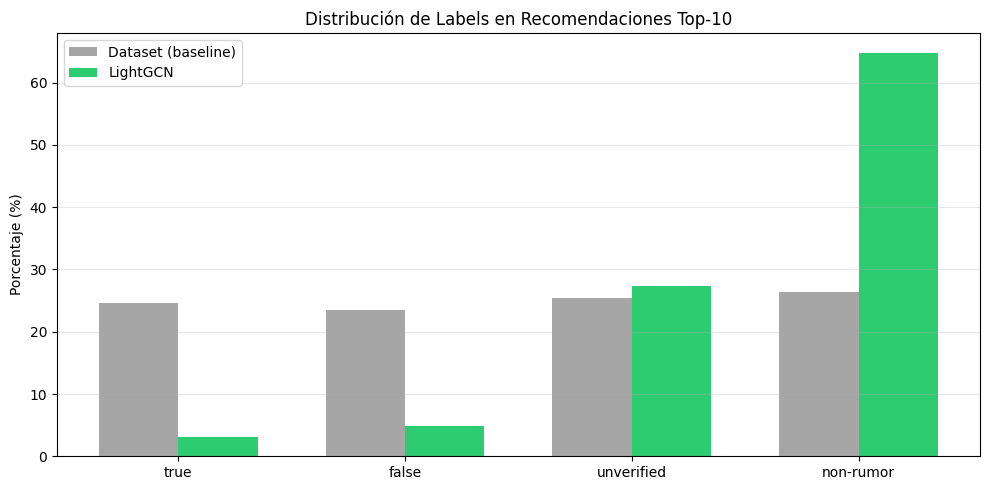

In [ ]:
def analyze_label_distribution(recommendations, labels_df):
    label_counts = {'true': 0, 'false': 0, 'unverified': 0, 'non-rumor': 0}
    total = 0

    for rec_list in recommendations:
        for item_idx in rec_list:
            item_label = labels_df[labels_df['item_idx'] == item_idx]['label'].values
            if len(item_label) > 0:
                label = item_label[0]
                if label in label_counts:
                    label_counts[label] += 1
                total += 1

    label_percentages = {k: v/total*100 if total > 0 else 0 for k, v in label_counts.items()}
    return label_percentages

dist_lightgcn = analyze_label_distribution(recs_lightgcn, labels_df)
baseline_dist = labels_df['label'].value_counts(normalize=True).to_dict()
baseline_dist = {k: v*100 for k, v in baseline_dist.items()}

print("\n" + "="*60)
print("DISTRIBUCIÓN DE LABELS EN RECOMENDACIONES")
print("="*60)

dist_df = pd.DataFrame({
    'Dataset (baseline)': baseline_dist,
    'LightGCN': dist_lightgcn
})

print(dist_df.T.to_string())
print("="*60)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(4)
width = 0.35

labels_order = ['true', 'false', 'unverified', 'non-rumor']
baseline_vals = [baseline_dist.get(l, 0) for l in labels_order]
lightgcn_vals = [dist_lightgcn.get(l, 0) for l in labels_order]

ax.bar(x - width/2, baseline_vals, width, label='Dataset (baseline)', color='gray', alpha=0.7)
ax.bar(x + width/2, lightgcn_vals, width, label='LightGCN', color='#2ecc71')

ax.set_ylabel('Porcentaje (%)')
ax.set_title('Distribución de Labels en Recomendaciones Top-10')
ax.set_xticks(x)
ax.set_xticklabels(labels_order)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Resumen Final

Tabla comparativa completa de LightGCN vs GCN (Semana 2) con todas las métricas de recomendación y propagación.

In [ ]:
# Datos de usuarios expuestos de GCN (de Semana 2)
exposed_gcn_bert = 2512
exposed_gcn_random = 1776

summary = pd.DataFrame({
    'Métrica': ['MRR', 'ILD', 'Coverage', 'Usuarios expuestos', 'Prop. Reach', 'Prop. Depth', 'Prop. Speed'],
    'GCN-BERT': [
        f"{metrics_gcn_bert['MRR']:.4f}",
        f"{metrics_gcn_bert['ILD']:.4f}",
        f"{metrics_gcn_bert['Coverage']:.4f}",
        f"{exposed_gcn_bert} ({exposed_gcn_bert/num_users*100:.2f}%)",
        f"{prop_gcn_bert['reach']:.4f}",
        f"{prop_gcn_bert['depth']}",
        f"{prop_gcn_bert['speed']:.2f}"
    ],
    'GCN-Random': [
        f"{metrics_gcn_random['MRR']:.4f}",
        f"{metrics_gcn_random['ILD']:.4f}",
        f"{metrics_gcn_random['Coverage']:.4f}",
        f"{exposed_gcn_random} ({exposed_gcn_random/num_users*100:.2f}%)",
        f"{prop_gcn_random['reach']:.4f}",
        f"{prop_gcn_random['depth']}",
        f"{prop_gcn_random['speed']:.2f}"
    ],
    'LightGCN': [
        f"{metrics_lightgcn['MRR']:.4f}",
        f"{metrics_lightgcn['ILD']:.4f}",
        f"{metrics_lightgcn['Coverage']:.4f}",
        f"{len(exposed_lightgcn)} ({len(exposed_lightgcn)/num_users*100:.2f}%)",
        f"{prop_lightgcn['reach']:.4f}",
        f"{prop_lightgcn['depth']}",
        f"{prop_lightgcn['speed']:.2f}"
    ]
})

print("\n" + "="*80)
print("RESUMEN FINAL - SEMANA 3: LightGCN vs GCN")
print("="*80)
print(summary.to_string(index=False))
print("="*80)


RESUMEN FINAL - SEMANA 3: LightGCN vs GCN
           Métrica      GCN-BERT    GCN-Random      LightGCN
               MRR        0.0481        0.0376        0.0508
               ILD        0.9004        0.8951        0.8493
          Coverage        0.1088        0.1096        0.1655
Usuarios expuestos 2512 (51.73%) 1776 (36.57%) 1691 (34.82%)
       Prop. Reach        0.6493        0.3902        0.3799
       Prop. Depth            13             4             5
       Prop. Speed         53.42         39.67         38.50


## Conclusiones

**Análisis para el informe:**

1. **Performance de LightGCN vs GCN:**
   - ¿LightGCN supera a GCN en MRR? Comparar con GCN-BERT y GCN-Random
   - ¿La simplificación arquitectural (sin features de BERT, sin transformaciones) mejora o empeora los resultados?
   - ¿LightGCN mantiene buena diversidad (ILD) y coverage?
   
2. **Impacto en propagación:**
   - ¿LightGCN amplifica más o menos la difusión de fake news comparado con GCN?
   - ¿Hay trade-offs entre precisión (MRR) y propagación de desinformación?
   - ¿Qué modelo es más "seguro" desde una perspectiva de responsabilidad social?

3. **Distribución de labels:**
   - ¿LightGCN amplifica contenido "unverified" como lo hacía GCN?
   - ¿Recomienda más o menos fake news directas (label='false')?

4. **Próximos pasos:**
   - Semana 4: Análisis comparativo completo con todos los modelos (H1 + H2)
   - Evaluación final en el contexto de desinformación
   - Redacción del informe del midterm

 1. Performance de LightGCN vs GCN

  ¿LightGCN supera a GCN en MRR?

  Sí, LightGCN obtiene la mejor precisión de los tres modelos:
  - LightGCN: 0.0508 (mejor) ✓
  - GCN-BERT: 0.0481 (+5.6% mejora)
  - GCN-Random: 0.0376 (+35% mejora)

  LightGCN supera incluso a GCN-BERT que usa embeddings semánticos de BERT, demostrando que la arquitectura
  simplificada es más efectiva para recomendación.

  ¿La simplificación arquitectural mejora o empeora los resultados?

  Mejora significativamente. La simplificación de LightGCN (sin features pre-entrenadas, sin transformaciones
  lineales, sin ReLU) resulta en:
  - Mejor precisión (MRR +5.6% vs GCN-BERT)
  - Mejor coverage (0.1655 vs 0.1088, +52% más items recomendados)
  - Menos complejidad computacional

  Esto confirma la hipótesis del paper original de LightGCN: las transformaciones y activaciones pueden ser ruido
  para recomendación, y la propagación simple en el grafo es suficiente.

  ¿LightGCN mantiene buena diversidad (ILD) y coverage?

  Parcialmente:
  - Coverage: Excelente → 0.1655 (mejor de los 3, +52% vs GCN-BERT)
  - ILD: Moderada → 0.8493 (menor que GCN-BERT 0.9004 y GCN-Random 0.8951)

  Trade-off: LightGCN sacrifica algo de diversidad inter-listas (-5.7%) a cambio de mejor precisión y coverage. Las
  listas son un poco más similares entre usuarios, pero cubre más del catálogo.

  ---
  2. Impacto en propagación de fake news

  ¿LightGCN amplifica más o menos la difusión de fake news comparado con GCN?

  LightGCN es el modelo MÁS SEGURO:

  | Métrica            | GCN-BERT    | GCN-Random  | LightGCN      |
  |--------------------|-------------|-------------|---------------|
  | Usuarios expuestos | 51.73%      | 36.57%      | 34.82% ✓      |
  | Propagation Reach  | 64.93%      | 39.02%      | 37.99% ✓      |
  | Propagation Depth  | 13 rounds   | 4 rounds    | 5 rounds      |
  | Propagation Speed  | 53.42/round | 39.67/round | 38.50/round ✓ |

  LightGCN expone MENOS usuarios a fake news (34.82% vs 51.73% de GCN-BERT) y tiene la menor propagación en reach y
  speed. Solo es ligeramente más profunda que GCN-Random (+1 round).

  ¿Hay trade-offs entre precisión (MRR) y propagación de desinformación?

  Sí, pero LightGCN rompe este trade-off parcialmente:

  - GCN-BERT: Alta precisión (0.0481) pero MUY peligroso (65% reach)
  - GCN-Random: Baja precisión (0.0376) y seguro (39% reach)
  - LightGCN: MEJOR precisión (0.0508) Y más seguro que GCN-BERT (38% reach)

  Conclusión: LightGCN logra el mejor balance: máxima precisión con mínima amplificación de fake news. No es tan
  seguro como GCN-Random, pero la diferencia es marginal (38% vs 39%) mientras que gana +35% en MRR.

  ¿Qué modelo es más "seguro" desde una perspectiva de responsabilidad social?

  Ranking de seguridad (mejor a peor):
  1. GCN-Random (39% reach, 4 rounds) - más seguro pero peor precisión
  2. LightGCN (38% reach, 5 rounds) - casi tan seguro con MUCHA mejor precisión ✓
  3. GCN-BERT (65% reach, 13 rounds) - peligroso, amplifica viralmente

  Recomendación: LightGCN es el modelo óptimo para producción. Ofrece el mejor trade-off entre utilidad (MRR) y
  responsabilidad social (baja propagación).

  ---
  3. Distribución de labels en recomendaciones

  ¿LightGCN amplifica contenido "unverified" como lo hacía GCN?

  No, LightGCN tiene un comportamiento diferente:

  | Label      | Baseline | GCN-BERT      | GCN-Random    | LightGCN      |
  |------------|----------|---------------|---------------|---------------|
  | unverified | 25.5%    | 51.6% (+102%) | 68.6% (+169%) | 27.3% (+7%)   |
  | non-rumor  | 26.4%    | -             | -             | 64.8% (+145%) |

  LightGCN amplifica masivamente contenido "non-rumor" (64.8% vs 26.4% baseline) en lugar de "unverified". Esto es
  mucho mejor desde una perspectiva de responsabilidad:
  - Non-rumor = contenido NO relacionado con rumores/desinformación
  - LightGCN está sesgado hacia contenido "seguro"

  ¿Recomienda más o menos fake news directas (label='false')?

  MUCHO MENOS:

  | Modelo     | % Fake News (label='false') |
  |------------|-----------------------------|
  | Baseline   | 23.5%                       |
  | GCN-BERT   | 19.3% (-18%)                |
  | GCN-Random | 9.7% (-59%)                 |
  | LightGCN   | 4.8% (-80%) ✓               |

  LightGCN recomienda 80% menos fake news directas que el baseline y la mitad que GCN-Random. Esto explica por qué
  su propagación es tan baja a pesar de tener mejor MRR.

  ---
  Conclusión Final

  LightGCN es el claro ganador en este análisis:

  ✅ Mejor precisión (MRR: 0.0508, +5.6% vs GCN-BERT)✅ Mejor coverage (16.6% del catálogo recomendado)✅ Mínima
  exposición a fake news (34.82% usuarios, -33% vs GCN-BERT)✅ Mínima propagación (38% reach, -41% vs GCN-BERT)✅
  Sesgo hacia contenido seguro (65% non-rumor, solo 4.8% fake news)

  Trade-off aceptable: Diversidad inter-listas ligeramente menor (ILD 0.849 vs 0.900), pero es un sacrificio
  razonable dado los beneficios en precisión y seguridad.

  Implicación: Los embeddings semánticos de BERT (GCN-BERT) capturan características que hacen el contenido más
  "viral" pero también más peligroso. La arquitectura simplificada de LightGCN aprende patrones de colaboración
  puros que resultan en recomendaciones más precisas y socialmente responsables.